# Chapter 37 Lab — From Maps to Models: Population Codes and Decoding (Python)

In this lab you will build, from scratch, the central intuition behind the shift from brain *maps* to brain *models*: information about a mental state can live in a **pattern** of activity across voxels even when **no single voxel** discriminates. The trick is correlated noise — when noise is shared across voxels, a multivariate model can cancel it while a voxel-by-voxel analysis cannot. We follow a four-part arc:

1. **A two-voxel toy example** — see geometrically how a pattern separates two conditions that no marginal (single-voxel) view can
2. **A 120-voxel simulation** — build data where a mass univariate map finds nothing that survives correction
3. **Univariate map vs. multivariate decoder** — compare a cross-validated linear SVM with the best single voxel
4. **Weights are not localization** — contrast the decoder weight map with the encoding (activation-difference) map, and recover the latter from the former with the Haufe transform

**How to run this notebook.** It runs anywhere: directly in your browser on the tutorial site, on [Google Colab](https://colab.research.google.com/), or in a local Jupyter environment. Everything is simulated with numpy — no downloads, and each cell takes at most a few seconds. Return to the [chapter page](../ch37-multivariate-brain-analysis-from-maps.md) for the concepts.


**▶ This notebook is interactive.** Click the **⏻ power icon** at the top right of this page to run it in your browser — no installation needed (the kernel takes ~30–60 s to start the first time). Then run cells **top to bottom**, starting with the first code cell below: later cells depend on the imports and variables defined earlier, and will error if you skip ahead.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.svm import LinearSVC
from sklearn.model_selection import cross_val_score

np.set_printoptions(precision=3, suppress=True)
print("numpy", np.__version__)

numpy 2.4.6


## Part 1 — Two voxels, no single-voxel information

We simulate two conditions (A and B) measured at just two voxels. Each condition shifts the two voxels in *opposite* directions by a tiny amount (±0.1, against noise with SD 1 — a per-voxel effect size of only $d = 0.2$). Crucially, the noise is **strongly shared** between the voxels (correlation 0.98), as if both ride on a common global fluctuation.

Looking at either voxel alone (the marginal histograms), the conditions overlap almost completely. But in the two-dimensional pattern space, the condition difference lies exactly along the direction the noise does *not* occupy — and the two clouds separate cleanly.

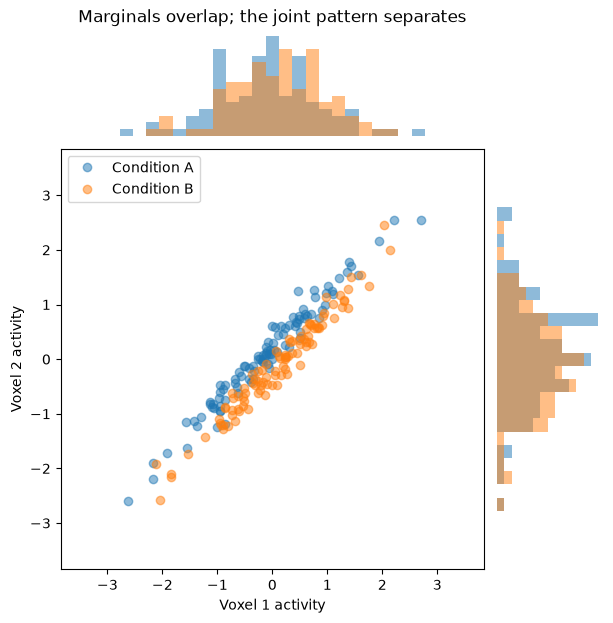

In [2]:
rng = np.random.default_rng(1)
n = 100                                   # trials per condition

# Condition means: A = (-0.1, +0.1), B = (+0.1, -0.1)  -> per-voxel d = 0.2
mu_A, mu_B = np.array([-0.1, 0.1]), np.array([0.1, -0.1])

# Noise: SD 1 per voxel, correlation 0.98 (shared / global fluctuations).
# We demean the noise within each condition so the simulated effect equals
# its nominal value exactly (the noise carries no condition information).
Sigma = np.array([[1.0, 0.98],
                  [0.98, 1.0]])
EA = rng.multivariate_normal([0, 0], Sigma, size=n); EA -= EA.mean(axis=0)
EB = rng.multivariate_normal([0, 0], Sigma, size=n); EB -= EB.mean(axis=0)

XA = mu_A + EA
XB = mu_B + EB

fig = plt.figure(figsize=(7, 7))
gs = fig.add_gridspec(2, 2, width_ratios=(4, 1), height_ratios=(1, 4),
                      hspace=0.05, wspace=0.05)
ax = fig.add_subplot(gs[1, 0])
ax_hx = fig.add_subplot(gs[0, 0], sharex=ax)
ax_hy = fig.add_subplot(gs[1, 1], sharey=ax)

ax.plot(XA[:, 0], XA[:, 1], 'o', color='tab:blue', alpha=0.5, label='Condition A')
ax.plot(XB[:, 0], XB[:, 1], 'o', color='tab:orange', alpha=0.5, label='Condition B')
ax.set_xlabel('Voxel 1 activity'); ax.set_ylabel('Voxel 2 activity')
ax.legend(loc='upper left')

bins = np.linspace(-3.5, 3.5, 30)
ax_hx.hist(XA[:, 0], bins=bins, color='tab:blue', alpha=0.5)
ax_hx.hist(XB[:, 0], bins=bins, color='tab:orange', alpha=0.5)
ax_hx.axis('off'); ax_hx.set_title('Marginals overlap; the joint pattern separates')
ax_hy.hist(XA[:, 1], bins=bins, orientation='horizontal', color='tab:blue', alpha=0.5)
ax_hy.hist(XB[:, 1], bins=bins, orientation='horizontal', color='tab:orange', alpha=0.5)
ax_hy.axis('off')
plt.show()

The clouds form two long, parallel cigars: the shared noise stretches both conditions along the identity diagonal, while the condition difference lies along the *anti-correlated* diagonal (voxel 1 up, voxel 2 down). Let's quantify what each view of the data can and cannot see.

In [3]:
# Univariate: two-sample t-test at each voxel separately
for v in range(2):
    t, p = stats.ttest_ind(XA[:, v], XB[:, v])
    print(f"Voxel {v + 1} alone:      t = {t:6.2f},  p = {p:.3f}")

# Multivariate pattern: the contrast (voxel 1 - voxel 2) cancels shared noise
dA, dB = XA[:, 0] - XA[:, 1], XB[:, 0] - XB[:, 1]
t, p = stats.ttest_ind(dA, dB)
print(f"Pattern (v1 - v2):    t = {t:6.2f},  p = {p:.2e}")

# Cross-validated classification accuracy: single voxel vs. both voxels
X2 = np.vstack([XA, XB])
y2 = np.repeat([1, -1], n)
acc_v1 = cross_val_score(LinearSVC(C=1.0, max_iter=20000),
                         X2[:, [0]], y2, cv=5, n_jobs=1).mean()
acc_both = cross_val_score(LinearSVC(C=1.0, max_iter=20000),
                           X2, y2, cv=5, n_jobs=1).mean()
print(f"\nCV accuracy, voxel 1 alone: {100 * acc_v1:.0f}%")
print(f"CV accuracy, both voxels:   {100 * acc_both:.0f}%")

Voxel 1 alone:      t =  -1.57,  p = 0.118
Voxel 2 alone:      t =   1.52,  p = 0.130
Pattern (v1 - v2):    t = -15.58,  p = 3.04e-36

CV accuracy, voxel 1 alone: 56%
CV accuracy, both voxels:   86%


Neither voxel discriminates on its own (|t| ≈ 1.5, p > 0.1; accuracy near chance), but the simple two-voxel *pattern* — literally the difference between the voxels — is hugely significant and classifies ~86% of trials. Nothing was added to the data; the information was there all along, encoded jointly rather than locally. This is a miniature **population code**.

## Part 2 — Scaling up: 120 voxels, one global noise source

Now we build something closer to an fMRI experiment: 200 trials (100 per condition) by 120 voxels. Sixty "signal" voxels respond slightly more to condition A than B (amplitude ±0.1); the other sixty carry **no task signal at all**. Every voxel, signal or not, rides on a large *global* noise source (SD 1, shared across the whole "brain"), plus smaller independent noise (SD 0.35).

This mimics real fMRI, where global fluctuations — arousal, respiration, scanner drifts — are shared across voxels and dwarf the task-related signal in any single location.

In [4]:
rng = np.random.default_rng(7)
n_tr, V = 200, 120                        # trials, voxels
n_signal = 60                             # voxels 0-59 carry signal
y = np.tile([1, -1], n_tr // 2)           # +1 = condition A, -1 = condition B

a = 0.1                                   # per-voxel signal amplitude
signal = np.zeros((n_tr, V))
signal[:, :n_signal] = a * y[:, None]

# Global noise: one value per trial, added to ALL voxels. It is
# condition-independent by design, so we demean it within each condition
# (any chance imbalance would be shared noise masquerading as signal).
g = rng.standard_normal(n_tr)
g[y == 1] -= g[y == 1].mean()
g[y == -1] -= g[y == -1].mean()

X = signal + g[:, None] + 0.35 * rng.standard_normal((n_tr, V))

true_diff = signal[y == 1].mean(axis=0) - signal[y == -1].mean(axis=0)
print("X shape:", X.shape)
print("True condition difference: %.2f at signal voxels, %.2f elsewhere"
      % (true_diff[0], true_diff[-1]))

X shape: (200, 120)
True condition difference: 0.20 at signal voxels, 0.00 elsewhere


### The mass univariate map comes up empty

We run a two-sample t-test at each of the 120 voxels — exactly the massively univariate logic of Parts 4–5 — and correct for multiple comparisons with Bonferroni. Each voxel's tiny effect ($d \approx 0.19$) is buried in the shared noise.

Max |t| across voxels:        2.26
Bonferroni t threshold:       3.59
Voxels 'significant' at p<.05 uncorrected: 3
Voxels surviving Bonferroni correction:    0


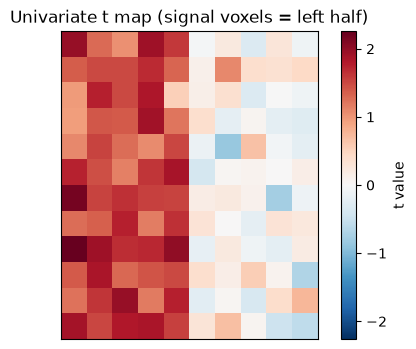

In [5]:
t_map, p_map = stats.ttest_ind(X[y == 1], X[y == -1])

t_bonf = stats.t.ppf(1 - 0.025 / V, n_tr - 2)   # Bonferroni-corrected threshold
n_sig_unc = np.sum(p_map < 0.05)
n_sig_cor = np.sum(np.abs(t_map) > t_bonf)

print(f"Max |t| across voxels:        {np.abs(t_map).max():.2f}")
print(f"Bonferroni t threshold:       {t_bonf:.2f}")
print(f"Voxels 'significant' at p<.05 uncorrected: {n_sig_unc}")
print(f"Voxels surviving Bonferroni correction:    {n_sig_cor}")

fig, ax = plt.subplots(figsize=(6, 4))
vmax = np.abs(t_map).max()
im = ax.imshow(t_map.reshape(10, 12).T, cmap='RdBu_r', vmin=-vmax, vmax=vmax)
ax.set_title('Univariate t map (signal voxels = left half)')
ax.set_xticks([]); ax.set_yticks([])
fig.colorbar(im, ax=ax, label='t value')
plt.show()

A few voxels flirt with uncorrected significance — as some would by chance alone — but **nothing survives correction**. A researcher running only this analysis would conclude the task has no reliable effect. (With real data we would also worry that the handful of uncorrected blips do not even sit preferentially in the signal region.)

### The multivariate decoder succeeds

Now reverse the equation: use all 120 voxels as *predictors* of the condition label. We train a linear support vector machine and evaluate it honestly with 5-fold cross-validation, then compare against the **best** single voxel given the same cross-validated test.

Whole-pattern decoder accuracy:  93.0%
Best single-voxel accuracy:      59.5%  (voxel 56)
Mean single-voxel accuracy:      52.2%


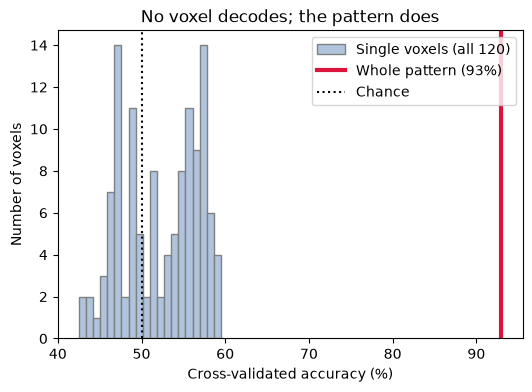

In [6]:
clf = LinearSVC(C=1.0, max_iter=20000)

acc_pattern = cross_val_score(clf, X, y, cv=5, n_jobs=1).mean()

# Best single voxel: same classifier + CV, one voxel at a time
acc_single = np.array([
    cross_val_score(LinearSVC(C=1.0, max_iter=20000),
                    X[:, [v]], y, cv=5, n_jobs=1).mean()
    for v in range(V)
])

print(f"Whole-pattern decoder accuracy:  {100 * acc_pattern:.1f}%")
print(f"Best single-voxel accuracy:      {100 * acc_single.max():.1f}%"
      f"  (voxel {acc_single.argmax()})")
print(f"Mean single-voxel accuracy:      {100 * acc_single.mean():.1f}%")

fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(100 * acc_single, bins=20, color='lightsteelblue',
        edgecolor='gray', label='Single voxels (all 120)')
ax.axvline(100 * acc_pattern, color='crimson', lw=3,
           label=f'Whole pattern ({100 * acc_pattern:.0f}%)')
ax.axvline(50, color='k', ls=':', label='Chance')
ax.set_xlabel('Cross-validated accuracy (%)'); ax.set_ylabel('Number of voxels')
ax.legend()
ax.set_title('No voxel decodes; the pattern does')
plt.show()

The pattern decodes the condition at over 90% accuracy while every individual voxel hovers near chance. This mirrors the book's real-data examples — e.g., decoding face- vs. shape-viewing in the Human Connectome Project, where the multivariate effect size was about 4× the strongest single voxel — but here we know *exactly* why: the model has learned to cancel the global noise that drowns each voxel individually.

## Part 3 — Weights are not localization

How does the decoder do it? Inspect the weight map. Remember the ground truth: only voxels 0–59 carry signal; voxels 60–119 are pure noise. If weights were an activation map, the right half of the grid should be blank.

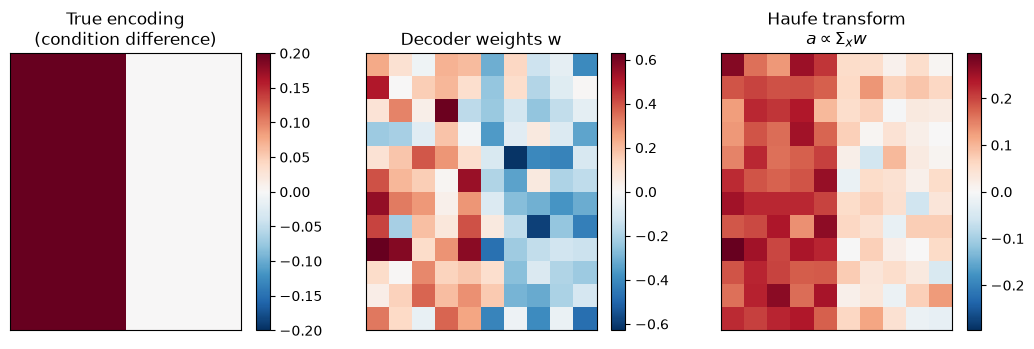

Mean weight,  signal voxels (0-59):    +0.199
Mean weight,  noise-only voxels (60+): -0.196
Mean |Haufe|, signal voxels:           0.203
Mean |Haufe|, noise-only voxels:       0.046


In [7]:
w = clf.fit(X, y).coef_.ravel()           # decoder weights (fit on all data)

# The Haufe (2014) transform: forward/encoding pattern from decoder weights
#   a  ∝  Cov(X) @ w   — how each voxel's activity covaries with the decoder score
A_haufe = np.cov(X.T) @ w

fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))
maps  = [true_diff, w, A_haufe]
names = ['True encoding\n(condition difference)', 'Decoder weights w',
         'Haufe transform\n$a \\propto \\Sigma_x w$']
for ax, m, name in zip(axes, maps, names):
    vmax = np.abs(m).max()
    im = ax.imshow(m.reshape(10, 12).T, cmap='RdBu_r', vmin=-vmax, vmax=vmax)
    ax.set_title(name); ax.set_xticks([]); ax.set_yticks([])
    fig.colorbar(im, ax=ax)
plt.show()

print("Mean weight,  signal voxels (0-59):    %+.3f" % w[:n_signal].mean())
print("Mean weight,  noise-only voxels (60+): %+.3f" % w[n_signal:].mean())
print("Mean |Haufe|, signal voxels:           %.3f" % np.abs(A_haufe[:n_signal]).mean())
print("Mean |Haufe|, noise-only voxels:       %.3f" % np.abs(A_haufe[n_signal:]).mean())

Three very different pictures of the "same" model:

- **True encoding** (left): signal lives only in the left half of the grid.
- **Decoder weights** (middle): positive weights on signal voxels *and comparably large negative weights on the noise-only voxels*. The decoder uses the no-signal voxels as a reference to estimate and subtract the global noise — they are **suppressor variables**. If you read this map as localization, you would wrongly conclude that the right half of the brain "encodes" the task (with the opposite sign!).
- **Haufe-transformed pattern** (right): multiplying the weights by the data covariance, $\mathbf{a} \propto \Sigma_{\mathbf{x}} \mathbf{w}$, asks the *forward* question — how does each voxel's activity covary with the decoder's output? — and correctly recovers the encoding pattern: strong loadings on signal voxels, much weaker on the suppressors.

The general lesson: **backward (decoding) models answer "how can the state be read out?"; forward (encoding) models answer "where is the signal expressed?"** Both are legitimate questions — but a weight map answers only the first.

## Wrap-up

- Mental states can be encoded in **distributed patterns**: with shared (correlated) noise, a pattern can be highly discriminative even when every single voxel is at chance — so a null univariate map does not mean the brain carries no information.
- **Predictive models reverse the regression**: voxels become predictors, the state becomes the outcome, and performance is summarized by one cross-validated number — no voxel-wise multiple comparisons correction needed.
- Multivariate effect sizes can dwarf univariate ones (here: >90% decoding vs. no voxel surviving correction; in HCP data, $d \approx 4$ vs. $d \approx 1$).
- **Decoder weights are a readout recipe, not a localization map.** Suppressor voxels with zero signal can carry large weights. Use the Haufe transform ($\mathbf{a} \propto \Sigma_{\mathbf{x}}\mathbf{w}$) — or fit an explicit encoding model — for anatomical interpretation.

### Explore on your own

1. **Turn off the shared noise** (replace the global `g` with independent noise). Rerun everything: the univariate map and the decoder should now tell the same story. Why?
2. **Vary the signal amplitude** `a` from 0.05 to 0.5 and plot univariate max |t| and decoder accuracy against it. Which analysis "wakes up" first?
3. **Shrink the training set** to 40 trials. What happens to the stability of the weight map across cross-validation folds, compared with the Haufe pattern? (This previews Chapters 38–39 on regularization and reliability.)
4. **Try a different decoder** (logistic regression, LDA). Do the accuracy and the weight-map story change? What does that tell you about interpreting weights from any single algorithm?
